In [37]:
# Calculate z-scores manually: (x - mean) / std
import pandas as pd
import numpy as np
from scipy import stats



input_file = "../data/ethiopia.csv"      
output_file = "../data/ethiopia_clean.csv"
country_name = "Ethiopia"

df = pd.read_csv(input_file)
df["Country"] = "Ethiopia"

df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

In [38]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,Year
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1,2015
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1,2015
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1,2015
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1,2015
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3,2026
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3,2026
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3,2026
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3,2026


In [39]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
df.drop_duplicates(inplace=True)

Duplicate rows: 0


In [40]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Year
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564,2020.131451
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000,2015.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000,2017.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000,2020.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000,2023.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000,2026.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046,3.248907


In [41]:
missing = df.isna().sum()
missing_pct = 100 * missing / len(df)
print(pd.concat([missing, missing_pct], axis=1, keys=['count', '%']))

             count    %
YEAR             0  0.0
DOY              0  0.0
T2M              0  0.0
T2M_MAX          0  0.0
T2M_MIN          0  0.0
T2M_RANGE        0  0.0
PRECTOTCORR      0  0.0
RH2M             0  0.0
WS2M             0  0.0
WS2M_MAX         0  0.0
PS               0  0.0
QV2M             0  0.0
Country          0  0.0
Date             0  0.0
Month            0  0.0
Year             0  0.0


In [42]:
cols = ['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']
z_scores = np.abs(stats.zscore(df[cols].dropna()))  
outliers = (z_scores > 3).sum(axis=0)
print(outliers)

[ 3  0 18 95 13  3  5]


In [43]:
weather_cols = ['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']
df[weather_cols] = df[weather_cols].ffill()
output_file = "../data/ethiopia_clean.csv"
# Drop rows that still have >30% missing values (after ffill)
threshold = 0.3 * len(df.columns)
before_drop = len(df)
df.dropna(thresh=len(df.columns) - threshold, inplace=True)
print(f"Rows dropped due to >30% missing: {before_drop - len(df)}")

df.to_csv(output_file, index=False)
print(f"Cleaned data saved to {output_file}")

Rows dropped due to >30% missing: 0
Cleaned data saved to ../data/ethiopia_clean.csv


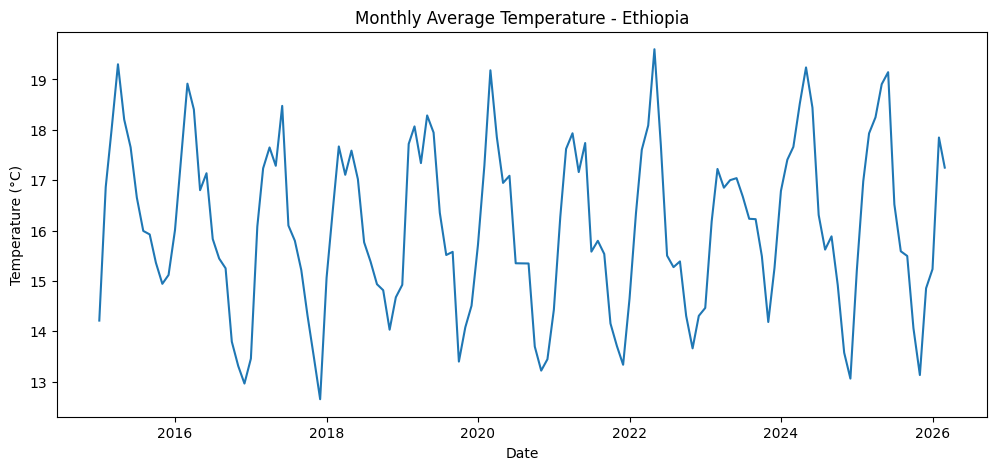

In [44]:
import matplotlib.pyplot as plt
df_clean = pd.read_csv("../data/ethiopia_clean.csv")
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
# If the Date column was saved as string, convert it back
monthly_t2m = df_clean.groupby(['Year','Month'])['T2M'].mean().reset_index()
monthly_t2m['Date'] = pd.to_datetime(monthly_t2m[['Year','Month']].assign(day=1))

plt.figure(figsize=(12,5))
plt.plot(monthly_t2m['Date'], monthly_t2m['T2M'])
plt.title('Monthly Average Temperature - Ethiopia')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()

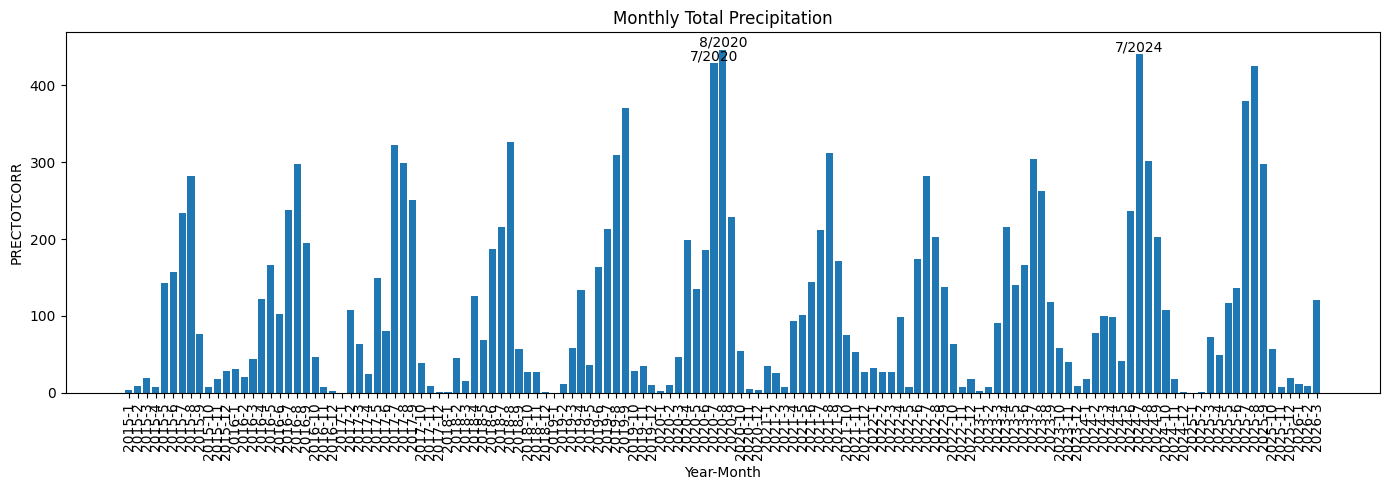

In [45]:
import matplotlib.pyplot as plt

monthly_precip = df_clean.groupby(['Year','Month'])['PRECTOTCORR'].sum().reset_index()

# create label like 2020-01
monthly_precip['YM'] = monthly_precip['Year'].astype(str) + '-' + monthly_precip['Month'].astype(str)

plt.figure(figsize=(14,5))
plt.bar(monthly_precip['YM'], monthly_precip['PRECTOTCORR'])

# find peak months
top = monthly_precip.nlargest(3, 'PRECTOTCORR')

# annotate
for _, row in top.iterrows():
    plt.text(
        x=monthly_precip.index[monthly_precip['YM']==row['YM']][0],
        y=row['PRECTOTCORR'],
        s=f"{row['Month']}/{row['Year']}",
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=90)
plt.title('Monthly Total Precipitation')
plt.ylabel('PRECTOTCORR')
plt.xlabel('Year-Month')

plt.tight_layout()
plt.show()

<Axes: >

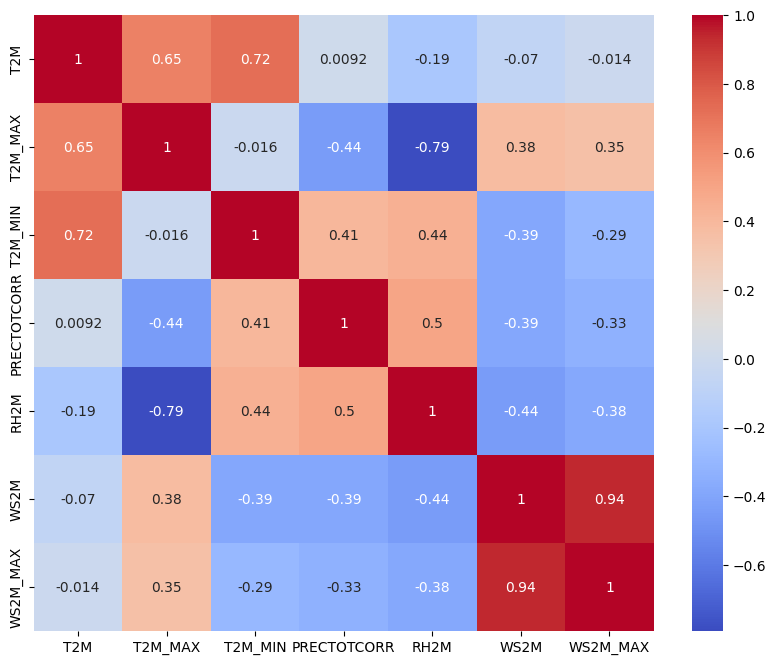

In [46]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df[weather_cols].corr(), annot=True, cmap='coolwarm')

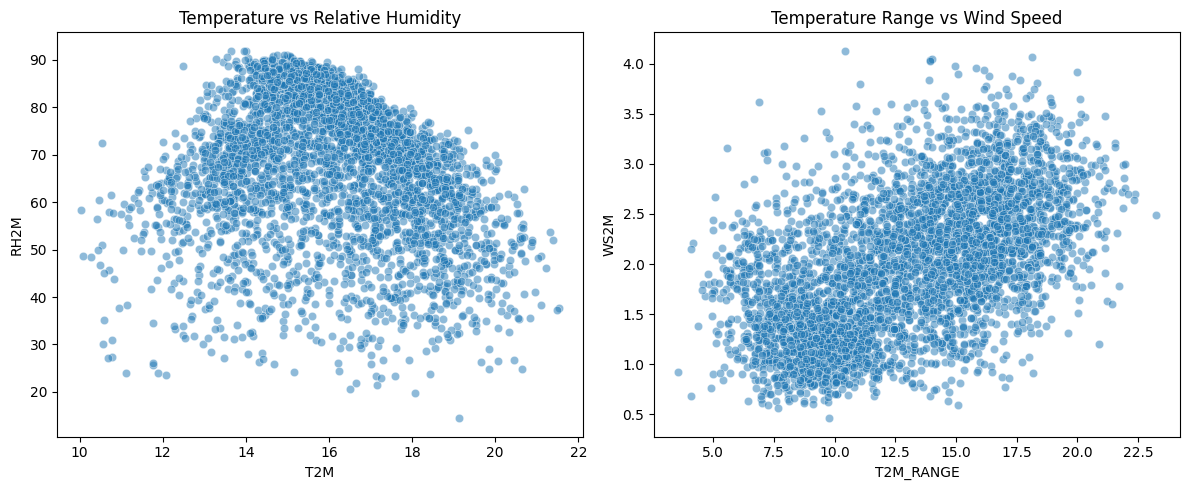

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a new column for temperature range
df_clean['T2M_RANGE'] = df_clean['T2M_MAX'] - df_clean['T2M_MIN']

# Create the two scatter plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Temperature vs Humidity
sns.scatterplot(data=df_clean, x='T2M', y='RH2M', ax=axes[0], alpha=0.5)
axes[0].set_title('Temperature vs Relative Humidity')

# Plot 2: Temperature range vs Wind speed
sns.scatterplot(data=df_clean, x='T2M_RANGE', y='WS2M', ax=axes[1], alpha=0.5)
axes[1].set_title('Temperature Range vs Wind Speed')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Rainfall distribution (log scale)')

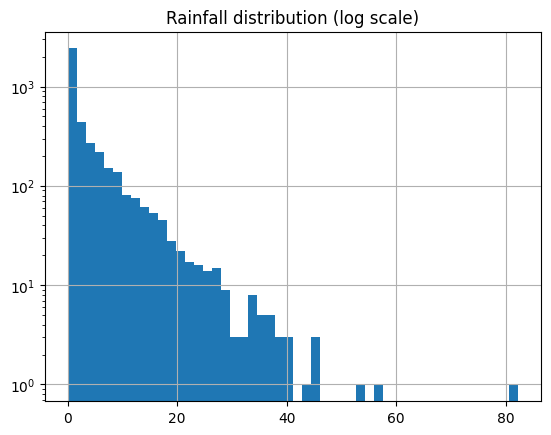

In [49]:
df_clean['PRECTOTCORR'].hist(bins=50, log=True)
plt.title('Rainfall distribution (log scale)')

Text(0, 0.5, 'Relative Humidity (%)')

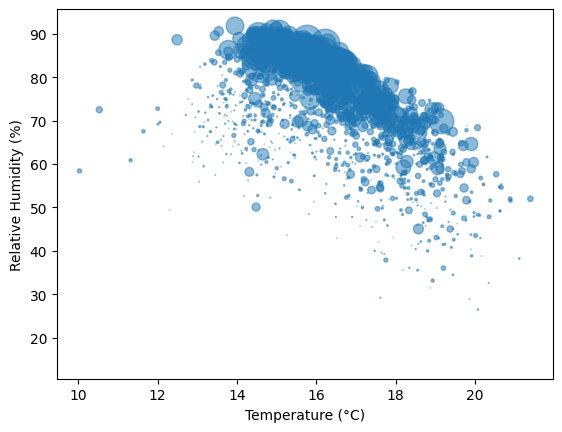

In [36]:
sample = df_clean.sample(min(2000, len(df_clean)))
plt.scatter(sample['T2M'], sample['RH2M'], s=sample['PRECTOTCORR']*10, alpha=0.5)
plt.xlabel('Temperature (°C)'); plt.ylabel('Relative Humidity (%)')